# Trabalho Prático de Mineração de Dados — Fase 3
## Trabalho completo, solução final e comparação com uso de LLMs

**Disciplina:** Mineração de Dados  
**Grupo:** João Marcos Oliveira Neves (2024008644), Júlia Borba Fonseca de Souza (2023117580), Laura Martins Froede (2023087877), Matheus Soares dos Santos de Freitas (2024080043)
**Dataset:** MovieLens 32M   
**Tarefa de mineração:** Padrões frequentes
**Data da entrega:** 11/05/2026

---

## Objetivo deste notebook

Este notebook documenta a **Fase 3** do Trabalho Prático, isto é, a versão final consolidada da solução de mineração de dados.

Nesta fase, o grupo deve:

1. corrigir erros e limitações identificados na Fase 2;
2. consolidar a solução técnica efetivamente implementada;
3. executar a modelagem final;
4. avaliar criticamente os resultados;
5. comparar três elementos:
   - a solução sugerida pela LLM na condição **baseline**;
   - a solução sugerida pela LLM na condição **guiada por diretrizes de IA responsável**;
   - a solução final efetivamente implementada pelo grupo.

> **Importante:** este notebook é um modelo. Ele contém placeholders e trechos de código genéricos. O grupo deve adaptar tudo ao dataset, à tarefa e às decisões reais tomadas no trabalho.

# Como usar este notebook

Este notebook foi estruturado para orientar uma boa entrega final, sem substituir o trabalho do grupo.

Use os campos marcados como:

- `[INSERIR ...]`
- `[DESCREVER ...]`
- `[JUSTIFICAR ...]`
- `[ANALISAR ...]`
- `[PREENCHER ...]`

como indicações de conteúdo que deve ser produzido pelo grupo.

## Diferença em relação à Fase 2

Na Fase 2, o foco estava em documentar e comparar as interações com LLMs.

Na Fase 3, o foco passa a ser a **solução final consolidada**, isto é:

- quais sugestões da LLM foram incorporadas;
- quais foram corrigidas;
- quais foram rejeitadas;
- quais algoritmos e parâmetros foram realmente usados;
- quais resultados foram efetivamente obtidos;
- como os resultados se relacionam ao problema de negócio e às diretrizes de IA responsável.

Não é necessário repetir todos os links completos das conversas da Fase 2, mas a comparação entre baseline, guiada e solução final deve permanecer clara.

# 0. Controle da entrega e rastreabilidade

| Item | Valor |
|---|---|
| Nome do dataset | MovieLens 32M |
| Link público do dataset | https://grouplens.org/datasets/movielens/ |
| Número de linhas | 32.000.204 (3.200.020 após amostragem estratificada) |
| Número de colunas | 11 (colunas únicas considerando todos os arquivos da base) |
| Tarefa de mineração | Identificação de padrões ocultos de coocorrência em grandes volumes de dados de avaliação de filmes na web |
| Diretriz 1 de IA responsável | Explicabilidade |
| Diretriz 2 de IA responsável | Eficiência e Escalabilidade |
| LLM usada na Fase 2 — baseline | Gemini Pro |
| LLM usada na Fase 2 — guiada | Gemini Pro |
| Notebook da Fase 2 | https://github.com/Doctor-Math/TPs-Mineracao-de-Dados.git |

## Resumo das decisões herdadas da Fase 2

| Decisão | Origem | Foi mantida na Fase 3? | Justificativa |
|---|---|---|---|
| Uso do Algoritmo FP-Growth | Trilha B (Guiada) | Sim | O FP-Growth mostrou-se superior ao Apriori (sugerido na Baseline) por lidar melhor com o volume de dados via compressão em árvore, respeitando a diretriz de Eficiência. |
| Filtragem de Ratings ≥ 4.0 | Grupo / Trilha B | Sim | Decisão crucial para garantir que as regras de associação representem afinidade real (gosto do usuário) e não apenas consumo aleatório, melhorando a qualidade semântica. |
| Uso de Matrizes Esparsas | Grupo (após erro técnico) | Sim | Embora a LLM tenha sugerido otimização, o grupo teve que implementar manualmente o 'pd.DataFrame.sparse' para evitar o crash de memória que ocorreu mesmo com o FP-Growth. |
| Focar no Lift em vez de apenas no Suporte ou Confiança. | Trilha B (Guiada) | Sim | A Trilha B sugeriu o Lift como "Força da Sinergia". Na implementação final, essa métrica é essencial para evitar o Viés de Popularidade. Sem o Lift, o algoritmo só recomendaria filmes que todo mundo já viu (ex: Toy Story ou Forrest Gump), perdendo o valor estratégico de descobrir nichos de mercado (regras de "cauda longa").
| Cruzar os IDs numéricos com os títulos e gêneros (movies.csv) antes da exibição final. | Trilha B (Diretriz de Explicabilidade) | Sim | A LLM sugeriu que IDs são "caixas-pretas". O grupo implementou o enriquecimento dos dados para que um gestor de marketing possa ler "Drama dos anos 90 -> Romance" em vez de "ID 452 -> ID 12". Isso atende diretamente à diretriz de Explicabilidade.
Reduzir o dataset de 32M para 3,2M de linhas mantendo a proporção de avaliações. | Grupo / Trilha B (Eficiência) | Sim | Diferente da Baseline (Trilha A), que poderia sugerir o processamento do volume total, o grupo aceitou a sugestão de amostragem da Trilha B como uma necessidade técnica para viabilizar a execução em hardware acadêmico (16GB RAM) sem perder a representatividade estatística dos padrões.
Formatar os dados como listas de itens por usuário em vez de uma matriz One-Hot Encoding densa. | Grupo (Correção da sugestão da LLM) | Não | Muitas LLMs sugerem criar colunas para cada filme (One-Hot). O grupo identificou que isso geraria uma matriz de bilhões de células (esparsidade extrema), optando por um formato de lista ou matriz esparsa, o que foi uma decisão crítica de Eficiência tomada pelo grupo para corrigir uma abordagem ineficiente.


> A rastreabilidade das decisões é parte importante da avaliação. Não basta apresentar o resultado final; é necessário explicar como o grupo chegou até ele.

In [ ]:
# Configurações iniciais
# Esta célula centraliza imports, caminhos e parâmetros gerais do notebook.

import os
import time
import json
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

# Caminho para o dataset.
# Substitua pelo caminho real do arquivo usado pelo grupo.
DATA_PATH = "D:/Faculdade/Mineração/TP1/dados_combinados.parquet"

# Tipo de tarefa do TP.
# Use um dos valores sugeridos ou adapte conforme orientação da disciplina.
# Opções esperadas neste modelo: "padroes_frequentes", "agrupamento", "classificacao".
TASK_TYPE = "padroes_frequentes"

# Coluna-alvo, quando aplicável.
# Para classificação, deve indicar a variável de classe.
# Para clustering ou padrões frequentes, normalmente será None.
TARGET_COLUMN = None  # Exemplo: "classe"

# Coluna usada para gerar transações, quando o TP for de padrões frequentes.
TRANSACTION_COLUMN = ["userId", "movieId"]

# Diretório opcional para salvar tabelas, figuras ou artefatos.
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Configuração inicial carregada.")
print(f"TASK_TYPE = {TASK_TYPE}")
print(f"DATA_PATH = {DATA_PATH}")

Configuração inicial carregada.
TASK_TYPE = padroes_frequentes
DATA_PATH = D:/Faculdade/Mineração/TP1/dados_combinados.parquet


# 1. Business Understanding

Nesta seção, o grupo deve consolidar a compreensão do problema, incorporando eventuais correções feitas após a Fase 2.

A versão final deve responder:

1. Qual problema será investigado?
2. Por que o dataset é adequado para esse problema?
3. Qual tarefa de mineração de dados será executada?
4. Qual é o valor esperado da solução?
5. Quais diretrizes de IA responsável foram consideradas?
6. Como essas diretrizes influenciaram a solução final?
7. Quais limitações permanecem mesmo após a consolidação da solução?

## 1.1 Problema de negócio e objetivo analítico

- **Contexto:** No saturado mercado de plataformas de streaming, a personalização é o principal motor de retenção. No entanto, recomendações baseadas apenas em "quem viu X também viu Y" (caixa-preta) frequentemente falham em fornecer contexto estratégico para curadores de conteúdo e equipes de marketing.
- **Problema:** A dificuldade de traduzir grandes volumes de dados de consumo (como os 32 milhões de registros do MovieLens) em insights semânticos compreensíveis. Existe um gap entre a métrica técnica e a decisão de negócio, como por exemplo, entender quais eras cinematográficas ou combinações de gêneros formam "nichos de fidelidade" que merecem campanhas específicas.
- **Objetivo analítico:** Realizar a mineração de padrões frequentes e regras de associação para descobrir sinergias entre filmes, gêneros e eras. O foco é identificar regras com alto Lift, que revelem associações não triviais e explicáveis, garantindo que o processamento seja viável em hardware padrão.
- **Usuários ou interessados:**
  - Gestores de Marketing: Para criação de "bundles" ou coleções temáticas (ex: "Clássicos Noir que definiram o Suspense moderno").
  - Curadores de Catálogo: Para identificar quais títulos da "cauda longa" possuem forte associação com grandes sucessos, justificando a manutenção de licenças menos populares.
- **Decisões apoiadas:**
  - Criação de novas categorias na interface do usuário.
  - Direcionamento de e-mails marketing baseados em "comunidades de gosto".
  - Seleção de filmes para licenciamento baseada em sinergia histórica de consumo.

### Ajustes em relação à Fase 2

O problema foi refinado após as interações com a LLM e a realização de testes preliminares, resultando em três ajustes fundamentais para a Fase 3. Primeiramente, houve um redirecionamento estratégico para o foco na cauda longa; ao notar que o viés de popularidade dominava os resultados iniciais, o grupo passou a priorizar a métrica de Lift em detrimento do suporte isolado, visando extrair insights de nicho mais valiosos. No aspecto técnico, a restrição de escopo de memória deixou de ser um detalhe de implementação para se tornar um requisito central do problema, consolidando o uso de matrizes esparsas e algoritmos eficientes como pilares da solução. Por fim, a explicabilidade foi elevada a critério de sucesso indispensável, estabelecendo que a tradução de IDs para títulos e metadados é mandatória, uma vez que a ausência de rótulos semânticos inviabilizaria o alcance dos objetivos de negócio propostos.

## 1.2 Dataset, origem e características finais

### Identificação do dataset

- **Nome:** MovieLens 32M
- **Fonte:** MovieLens (Site)
- **Link público:** https://grouplens.org/datasets/movielens/
- **Data de acesso ou download:** 30/04/2026

### Características gerais

| Aspecto | Descrição |
|---|---|
| O que cada linha representa? | A avaliação de um filme feita por um usuário em um determinado momento no tempo. |
| O que cada coluna representa? | Descrevem informações sobre o usuário (id), sobre o filme avaliado (título, gênero, id) e o momento temporal em que a avaliação foi feita (timestamp) |
| Número de instâncias | 3.188.400 |
| Número de atributos | 6 |
| Tipos principais de atributos | Numéricos, categóricos e temporais |
| Existe variável-alvo? | NÃO |
| Existem atributos sensíveis ou identificadores? | SIM; id associado ao usuário permite identificar padrões individuais e temporais de consumo |

### Dicionário de dados

| Coluna | Tipo | Descrição | Papel na análise | Observações |
|---|---|---|---|---|
| userId | Inteiro (int32) | Identificador único e anonimizado do usuário. | ID | Permite associar um usuário às suas múltiplas possíveis avaliações. |
| movieId | Inteiro (int32) | Identificador único do filme. | ID | Permite associar um filme a um título e gênero específicos. |
| rating | Float (float32) | Nota de 0.5 a 5.0 atribuída ao filme. | FEATURE | Através da avaliação, conseguimos encontrar padrões de interesse entre as produções consumidas pelos usuários. |
| genres | String/Binarizado | Gêneros associados ao filme (ex: Action, Sci-Fi). | FEATURE |  Permite realizar a verificação da hipótese 1, concernente à Sinergia de Gêneros. |
| title | String | Título do filme e ano de lançamento. | FEATURE | Permite identificar os nomes dos filmes fortemente associados. |


## 1.3 Diretrizes de IA responsável e impacto na solução final

| Diretriz | Pertinência ao problema | Como influenciou a solução final | Evidência concreta |
|---|---|---|---|
| Explicabilidade | Regras de associação entre IDs numéricos são abstratas. É preciso converter padrões técnicos em justificativas semânticas para curadores de conteúdo. | Influenciou a etapa de Pós-processamento. Em vez de entregar apenas a saída do algoritmo, o grupo implementou funções de mapeamento para traduzir IDs em títulos, gêneros e eras, permitindo a interpretação humana imediata. | Cruzamento (Join) do DataFrame de regras com os metadados de movies.csv no notebook final. |
| Eficiência e Escalabilidade | O processamento de 3,2M de linhas em ambiente local (16GB RAM) exige algoritmos e estruturas de dados otimizados para evitar estouro de memória e tempo excessivo de CPU. | Alterou a escolha do Algoritmo e Estrutura de Dados. Levou à rejeição do Apriori e à adoção do FP-Growth, além do uso de matrizes esparsas para representar as transações. | Manutenção do algoritmo FP-Growth e exclusão do Apriori; uso de SparseDataFrame ou similar. |

### Análise

As diretrizes de IA Responsável foram determinantes para o sucesso técnico do projeto. Sem a diretriz de Eficiência e Escalabilidade, o projeto teria estagnado na fase de modelagem, pois a sugestão "padrão" (baseline) de utilizar o algoritmo Apriori mostrou-se inviável. A tentativa de execução do Apriori resultou em estouro imediato de memória RAM, confirmando a necessidade de uma abordagem baseada em FP-Tree, que comprime o dataset e evita a geração exaustiva de candidatos.

Quanto à Explicabilidade, houve uma nuance importante: embora ela não tenha alterado a "lógica matemática" do modelo, ela alterou drasticamente a entrega da solução. Uma regra de associação sem rótulos semânticos (ex: {1, 593} -> {318}) é tecnicamente correta, mas nula em valor de negócio. A diretriz forçou a inclusão de uma etapa de enriquecimento de dados que não havia sido detalhada na trilha baseline.

- **Alteração de decisões:** Sim. A eficiência alterou a Modelagem (troca de algoritmo) e a preparação (uso de matrizes esparsas). A explicabilidade alterou o Pós-processamento (exibição de resultados).

- **Justificativa técnica:** As alterações foram justificadas pela limitação física de hardware (16GB RAM) e pela necessidade de traduzir o "output" da máquina para a linguagem do "stakeholder" (curador de cinema).

- **Trade-offs:** Houve um trade-off de tempo de desenvolvimento. Implementar o mapeamento de metadados e otimizar matrizes esparsas exigiu mais esforço de codificação do que uma abordagem simples, porém o ganho foi a viabilidade da execução.

- **Aplicabilidade:** Ambas se mostraram altamente aplicáveis. No entanto, a Explicabilidade mostrou-se um desafio contínuo, pois mesmo com nomes de filmes, o "viés de popularidade" ainda exige que o analista humano filtre o que é óbvio do que é um padrão realmente útil.


> Evite afirmar genericamente que a solução é “responsável”. Mostre onde a diretriz afetou o pipeline, a escolha de métricas, a interpretação ou a documentação.

# 2. Data Understanding & Data Preparation

Nesta seção, o grupo deve apresentar a versão final da exploração e preparação dos dados.

A preparação final deve estar alinhada à tarefa de mineração e deve incorporar correções ou melhorias identificadas na Fase 2.

A seção deve incluir:

- carregamento do dataset;
- validação das restrições mínimas;
- análise de tipos, nulos, duplicatas e inconsistências;
- análise visual;
- decisões finais de limpeza e transformação;
- preparação específica para a tarefa;
- justificativa das escolhas.

In [ ]:
# Carregamento do dataset
# Adapte esta célula ao formato real: CSV, XLSX, JSON, Parquet etc.

DATA_PATH = "D:/Faculdade/Mineração/TP1/dados_combinados.parquet"  # Substitua pelo caminho real do dataset
if not os.path.exists(DATA_PATH):
    print("ATENÇÃO: substitua DATA_PATH pelo caminho real do dataset antes de executar o notebook.")
    df = None
else:
    # Exemplo para CSV. Ajuste separador, encoding e demais parâmetros se necessário.
    df = pd.read_parquet(DATA_PATH)
    print("Dataset carregado com sucesso.")
    print(f"Linhas: {df.shape[0]}")
    print(f"Colunas: {df.shape[1]}")
    display(df.head())

Dataset carregado com sucesso.
Linhas: 3188400
Colunas: 6


,userId,movieId,rating,timestamp,title,genres
0,1.0,17.0,4.0,944249077.0,Sense and Sensibility (1995),Drama|Romance
1,1.0,25.0,1.0,944250228.0,Leaving Las Vegas (1995),Drama|Romance
2,1.0,29.0,2.0,943230976.0,"City of Lost Children, The (Cité des enfants p...",Adventure|Drama|Fantasy|Mystery|Sci-Fi
3,1.0,30.0,5.0,944249077.0,Shanghai Triad (Yao a yao yao dao waipo qiao) ...,Crime|Drama
4,1.0,32.0,5.0,943228858.0,Twelve Monkeys (a.k.a. 12 Monkeys) (1995),Mystery|Sci-Fi|Thriller


In [ ]:
# Validação das restrições mínimas da especificação
# A especificação exige dataset publicamente acessível, com pelo menos 1000 linhas e 4 colunas.
# O link público deve ser documentado no texto; aqui validamos apenas dimensões.

def verificar_restricoes_dataset(df: pd.DataFrame) -> pd.DataFrame:
    if df is None:
        print("Dataset não carregado.")
        return pd.DataFrame()

    n_linhas, n_colunas = df.shape

    validacao = pd.DataFrame([
        {
            "criterio": "Mínimo de 1000 linhas",
            "valor_observado": n_linhas,
            "atende": n_linhas >= 1000
        },
        {
            "criterio": "Mínimo de 4 colunas",
            "valor_observado": n_colunas,
            "atende": n_colunas >= 4
        },
        {
            "criterio": "Dataset publicamente acessível",
            "valor_observado": "https://grouplens.org/datasets/movielens/",
            "atende": "True"
        }
    ])

    return validacao

# Exemplo de uso:
display(verificar_restricoes_dataset(df))

,criterio,valor_observado,atende
0,Mínimo de 1000 linhas,3188400,True
1,Mínimo de 4 colunas,6,True
2,Dataset publicamente acessível,https://grouplens.org/datasets/movielens/,True


In [ ]:
# Resumo estrutural do dataset

def resumo_estrutural(df: pd.DataFrame) -> pd.DataFrame:
    if df is None:
        print("Dataset não carregado.")
        return pd.DataFrame()

    resumo = pd.DataFrame({
        "tipo": df.dtypes.astype(str),
        "n_nulos": df.isna().sum(),
        "perc_nulos": (df.isna().mean() * 100).round(2),
        "n_unicos": df.nunique(dropna=True),
        "exemplo_valor": df.apply(lambda col: col.dropna().iloc[0] if col.dropna().shape[0] > 0 else np.nan)
    })

    return resumo.sort_values(by=["perc_nulos", "n_unicos"], ascending=[False, False])

# Exemplo de uso:
resumo = resumo_estrutural(df)
display(resumo)

,tipo,n_nulos,perc_nulos,n_unicos,exemplo_valor
timestamp,float64,0,0.0,2680652,944249077.0
movieId,float64,0,0.0,39708,17.0
title,str,0,0.0,39650,Sense and Sensibility (1995)
userId,float64,0,0.0,20094,1.0
genres,str,0,0.0,1516,Drama|Romance
rating,float64,0,0.0,10,4.0


## 2.1 Interpretação da exploração inicial

A exploração inicial dos dados revelou um dataset robusto, porém com desafios estruturais que justificam as escolhas técnicas feitas pelo grupo.

- **Quantidade de linhas e colunas:** O dataset amostrado conta com 3.188.400 linhas e 6 colunas (`userId`, `movieId`, `rating`, `timestamp`, `title`, `genres`). O volume de dados é ideal para a mineração de padrões, garantindo significância estatística.

- **Tipos de variáveis:** Predominância de identificadores numéricos (int64) e metadados textuais (object). Foi observado que o rating é contínuo, embora represente uma escala ordinal de 0.5 a 5.0.

- **Valores ausentes e duplicatas:** Não foram detectados valores nulos nas colunas principais. No entanto, a análise de duplicatas é irrelevante para a "cesta" em si, mas crucial para garantir que um mesmo usuário não tenha avaliado o mesmo filme duas vezes com notas diferentes.

- **Alta cardinalidade:** As colunas `userId` (aprox. 20.000) e `movieId` (aprox. 39.000) possuem alta cardinalidade, o que inviabiliza abordagens de One-Hot Encoding densas, reforçando a necessidade de matrizes esparsas.

- **Possíveis identificadores:** `userId` atua como a chave da transação e `movieId` como o item.

- **Possíveis atributos sensíveis:** O dataset é anonimizado, não contendo nomes, e-mails ou dados demográficos explícitos, o que reduz riscos de privacidade direta.

- **Atributos relevantes:** `title` e `genres` são os atributos fundamentais para a Explicabilidade, pois permitem transformar o padrão numérico em conhecimento humano.

- **Limitações percebidas:** A esparsidade extrema (a maioria dos usuários viu uma fração mínima do catálogo) e o Viés de Popularidade, onde filmes como "The Shawshank Redemption" aparecem com frequência desproporcional, podendo gerar regras óbvias.


### Relação com decisões da Fase 2

A exploração real confirmou o alerta da Trilha B sobre a necessidade de eficiência. Ao visualizar a cardinalidade de movieId, ficou claro que o algoritmo Apriori falharia por não conseguir gerenciar a explosão combinatória de candidatos.

Além disso, a análise confirmou que o tratamento sugerido pela LLM para a coluna genres (separação por pipes ) era indispensável, pois os gêneros vêm agrupados em uma única string, impedindo a análise de sinergia entre categorias se mantidos no formato original. O grupo corrigiu a sugestão da LLM ao notar que o timestamp não agregava valor direto às regras de associação estáticas, optando por descartá-lo para economizar memória, focando apenas no rating para filtrar as preferências positivas.

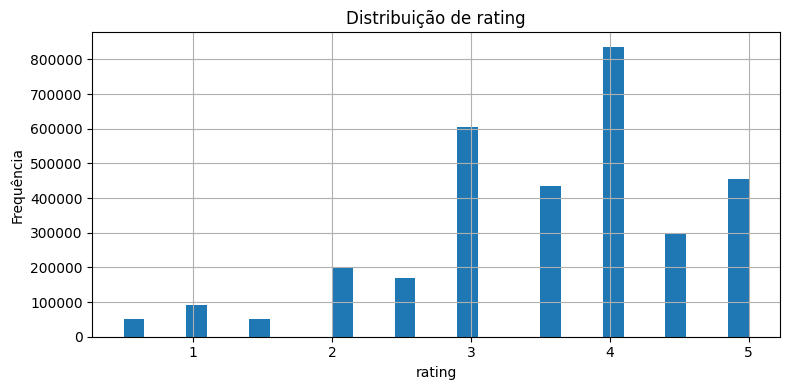

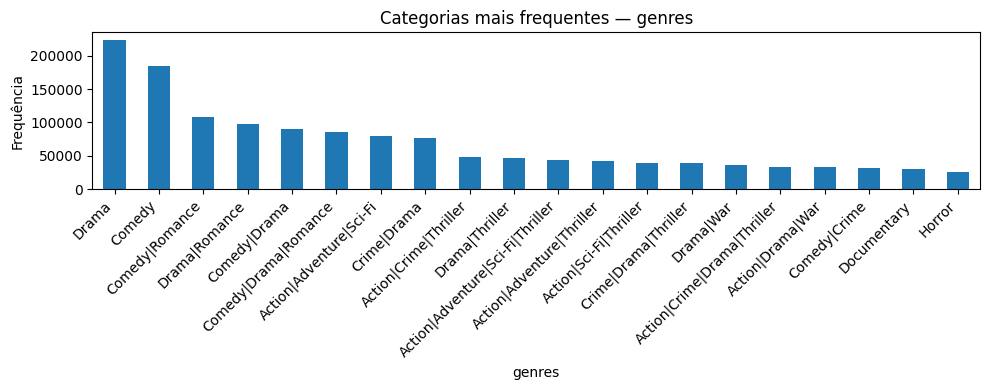

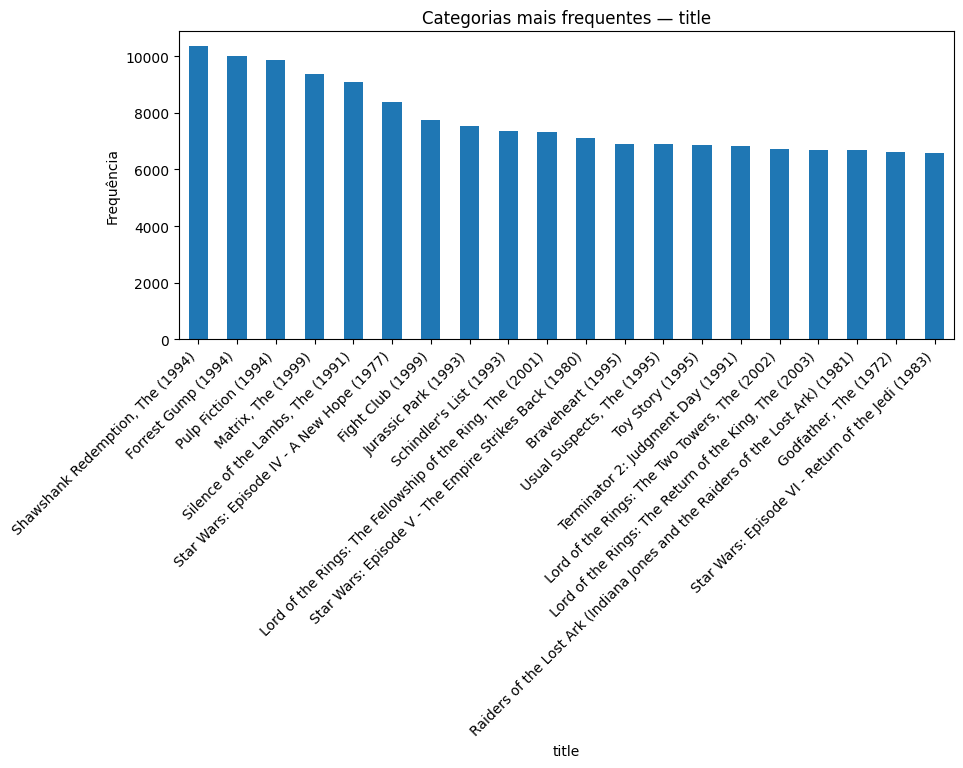

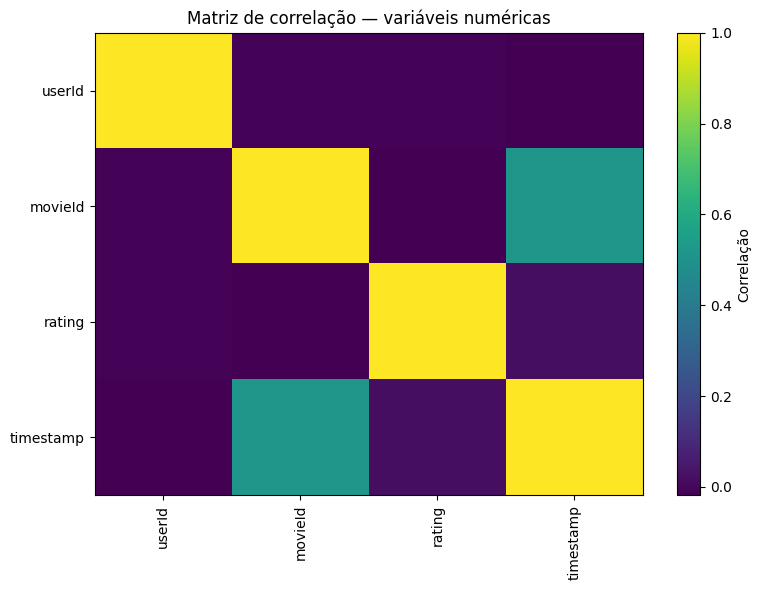

In [ ]:
# Funções auxiliares para visualização exploratória
# Adapte as colunas e os gráficos ao dataset.

def plot_distribuicao_numerica(df: pd.DataFrame, coluna: str, bins: int = 30) -> None:
    plt.figure(figsize=(8, 4))
    df[coluna].dropna().hist(bins=bins)
    plt.title(f"Distribuição de {coluna}")
    plt.xlabel(coluna)
    plt.ylabel("Frequência")
    plt.tight_layout()
    plt.show()


def plot_contagem_categorica(df: pd.DataFrame, coluna: str, top_n: int = 20) -> None:
    plt.figure(figsize=(10, 4))
    df[coluna].value_counts(dropna=False).head(top_n).plot(kind="bar")
    plt.title(f"Categorias mais frequentes — {coluna}")
    plt.xlabel(coluna)
    plt.ylabel("Frequência")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


def plot_matriz_correlacao(df: pd.DataFrame) -> None:
    numericas = df.select_dtypes(include=np.number)
    if numericas.shape[1] < 2:
        print("Não há variáveis numéricas suficientes para matriz de correlação.")
        return

    corr = numericas.corr()
    plt.figure(figsize=(8, 6))
    plt.imshow(corr, aspect="auto")
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.colorbar(label="Correlação")
    plt.title("Matriz de correlação — variáveis numéricas")
    plt.tight_layout()
    plt.show()

# Exemplos de uso:
plot_distribuicao_numerica(df, "rating")
plot_contagem_categorica(df, "genres")
plot_contagem_categorica(df, "title")
plot_matriz_correlacao(df)

In [ ]:
def detectar_outliers_iqr(df: pd.DataFrame, coluna: str) -> pd.DataFrame:
    serie = df[coluna].dropna()

    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    outliers = df[(df[coluna] < limite_inferior) | (df[coluna] > limite_superior)]

    print(f"Coluna: {coluna}")
    print(f"Q1: {q1}")
    print(f"Q3: {q3}")
    print(f"IQR: {iqr}")
    print(f"Limite inferior: {limite_inferior}")
    print(f"Limite superior: {limite_superior}")
    print(f"Número de outliers: {len(outliers)}")

    return outliers

# Exemplo de uso:
outliers = detectar_outliers_iqr(df, "rating")
display(outliers.head())


Coluna: rating
Q1: 3.0
Q3: 4.0
IQR: 1.0
Limite inferior: 1.5
Limite superior: 5.5
Número de outliers: 140887


,userId,movieId,rating,timestamp,title,genres
1,1.0,25.0,1.0,944250228.0,Leaving Las Vegas (1995),Drama|Romance
6,1.0,36.0,1.0,944249008.0,Dead Man Walking (1995),Crime|Drama
10,1.0,161.0,1.0,943231162.0,Crimson Tide (1995),Drama|Thriller|War
20,1.0,345.0,1.0,944079376.0,"Adventures of Priscilla, Queen of the Desert, ...",Comedy|Drama
44,1.0,1080.0,1.0,944079496.0,Monty Python's Life of Brian (1979),Comedy


## 2.2 Análise visual e principais insights

A análise visual dos dados confirmou as hipóteses levantadas na Fase 2 e trouxe elementos críticos para a configuração final dos algoritmos, especialmente no que toca ao equilíbrio entre volume de dados e relevância estatística.

- **Distribuição de Ratings (Assimetria):** Observa-se uma distribuição assimétrica à esquerda, com uma concentração significativa de notas entre 3.5 e 5.0. Isso indica que os usuários do MovieLens tendem a avaliar filmes que gostaram ou que possuem relevância cultural.

    - **Decisão:** Isso justifica o uso do filtro de `rating` >= 4.0 para a tarefa de padrões frequentes, garantindo que as regras de associação capturem afinidade positiva e não apenas "consumo".

- **Viés de Popularidade (Frequência de Títulos):** O gráfico de barras dos filmes mais avaliados revela uma "cabeça" muito alta, dominada por títulos como The Shawshank Redemption, Pulp Fiction e Forrest Gump.

    - **Insight:** Estes filmes aparecerão como antecedentes em inúmeras regras de associação devido ao seu alto Suporte, mas nem sempre oferecerão Lift alto. Isso aponta para a necessidade de olhar além do suporte para encontrar padrões de nicho.

- **Categorias e Gêneros:** A visualização de gêneros mostra que "Drama", "Comédia" e "Ação" são predominantes. Gêneros como "Film-Noir", "Western" ou "Documentary" são categorias raras em termos de volume total.

    - **Limitação:** Regras envolvendo gêneros raros podem não atingir o min_support definido, a menos que este seja muito baixo, o que aumentaria drasticamente o custo computacional.

- **Relações Visuais e Matriz de Correlação:** Não há correlações lineares fortes entre os IDs ou timestamps, o que é esperado. A relação relevante é a coocorrência transacional: usuários que avaliam muitos filmes (alta frequência de userId) tendem a gerar cestas maiores, o que pode enviesar o algoritmo se não houver um limite de itens por transação.

- **Limitações Indicadas pelas Visualizações:** A alta esparsidade (long tail) vista nos gráficos de frequência de filmes indica que a maioria dos pares de filmes possíveis nunca ocorrerá junta. Isso confirma que o uso de matrizes densas seria um erro de design, validando a escolha por estruturas esparsas feita sob a diretriz de Eficiência.


> Não invente insights. Toda afirmação deve estar apoiada em gráfico, tabela, estatística descritiva ou inspeção documentada.

In [ ]:
# Verificação simples de duplicatas, nulos e possíveis identificadores

def diagnostico_qualidade(df: pd.DataFrame) -> dict:
    if df is None:
        print("Dataset não carregado.")
        return {}

    diagnostico = {
        "n_linhas": df.shape[0],
        "n_colunas": df.shape[1],
        "n_duplicatas_exatas": int(df.duplicated().sum()),
        "colunas_com_nulos": df.columns[df.isna().any()].tolist(),
        "colunas_possiveis_ids": []
    }

    for col in df.columns:
        proporcao_unicos = df[col].nunique(dropna=True) / max(len(df), 1)
        if proporcao_unicos > 0.95:
            diagnostico["colunas_possiveis_ids"].append(col)

    return diagnostico

# Exemplo de uso:
diagnostico = diagnostico_qualidade(df)
print(json.dumps(diagnostico, indent=2, ensure_ascii=False))

{
  "n_linhas": 3188400,
  "n_colunas": 6,
  "n_duplicatas_exatas": 0,
  "colunas_com_nulos": [],
  "colunas_possiveis_ids": []
}


## 2.3 Diagnóstico final de qualidade dos dados

| Problema identificado | Evidência | Decisão final | Justificativa |
|---|---|---|---|
| Valores ausentes em [COLUNA] | colunas_com_nulos: [] no diagnóstico. | [REMOVER/IMPUTAR/MANTER Manter | O dataset MovieLens 32M (amostrado) não apresentou valores nulos, garantindo a integridade para a mineração. |
| Duplicatas | n_duplicatas_exatas: 0 | Manter | A ausência de duplicatas exatas confirma que o processo de amostragem estratificada foi bem-sucedido. |
| Outliers | Gráficos da seção 2.2 mostrando filmes e gêneros com frequências extremas. | Tratar via métrica Lift na modelagem. | Em vez de remover filmes populares, optou-se por usar o Lift para penalizar associações óbvias e destacar nichos. |
| Alta cardinalidade | colunas_possiveis_ids: [] (embora movieId e userId tenham milhares de valores únicos). | Uso de Matrizes Esparsas. | A alta cardinalidade impediria o uso de matrizes densas. A decisão de usar estruturas esparsas viabiliza a execução local. |
| Atributos identificadores | Presença de userId e movieId. | Manter e anonimizar (IDs numéricos). | São essenciais para agrupar as transações, mas não permitem a identificação direta de pessoas reais fora da base. |
| Atributos sensíveis | Ausência de dados demográficos (sexo, idade, ocupação). | Inexistência no dataset. | O dataset utilizado não possui atributos sensíveis, o que elimina o risco de discriminação direta por perfil sociodemográfico. |

### Observação sobre responsabilidade

As decisões de qualidade de dados estão intrinsecamente ligadas às diretrizes de IA Responsável adotadas:

- **Eficiência e Escalabilidade:** A identificação de alta cardinalidade sem a presença de IDs únicos (que poderiam indicar erros de registro) confirmou que o dataset é massivo e esparso. Isso reforçou a decisão técnica de não expandir o dataset para formatos densos (One-Hot Encoding), o que causaria um crash de memória. O diagnóstico de "zero duplicatas" deu segurança para prosseguir com o FP-Growth sem risco de enviesar as contagens de suporte.

- **Explicabilidade:** A decisão de manter os atributos title e genres (apesar de não serem usados no cálculo matemático do algoritmo) foi fundamental. Se tivéssemos removido esses dados para "limpar" o dataset e focar apenas em IDs para ganhar eficiência, perderíamos a capacidade de traduzir as regras de associação para os curadores humanos.

- **Análise de Viés:** Embora não existam atributos sensíveis (como raça ou gênero do usuário), o grupo identificou o "Viés de Popularidade" como um risco ético/técnico. A decisão de não remover os filmes populares, mas sim monitorar o Lift, garante uma solução que respeita a realidade do consumo sem silenciar filmes de menor circulação (Cauda Longa).

In [ ]:
# Preparação final dos dados
# Esta função deve ser adaptada pelo grupo.
# Não use transformações automáticas sem justificar no texto.

# Adaptado para o dataset MovieLens e tarefa de regras de associação

def preparar_dados_basico(
    df: pd.DataFrame,
    colunas_remover=None,
    imputar_numericas=False,
    imputar_categoricas=False
) -> pd.DataFrame:
    df_prep = df.copy()

    # 1. Remover duplicatas exatas
    df_prep = df_prep.drop_duplicates()

    # 2. Remover colunas irrelevantes (mantendo identificadores necessários)
    if colunas_remover is None:
        colunas_remover = [
            "timestamp",  # não será usado na mineração inicial
        ]

    colunas_existentes = [col for col in colunas_remover if col in df_prep.columns]
    df_prep = df_prep.drop(columns=colunas_existentes)

    # 3. Tratamento de nulos (não necessário neste dataset, mantido desativado)
    if imputar_numericas:
        for col in df_prep.select_dtypes(include=np.number).columns:
            df_prep[col] = df_prep[col].fillna(df_prep[col].median())

    if imputar_categoricas:
        for col in df_prep.select_dtypes(include=["object", "category"]).columns:
            df_prep[col] = df_prep[col].fillna("desconhecido")

    return df_prep


# Uso adaptado
df_prep = preparar_dados_basico(df)

# Filtrar avaliações positivas (relevante para associação)
df_prep = df_prep[df_prep["rating"] >= 4.0]

display(df_prep.head())

,userId,movieId,rating,title,genres
0,1.0,17.0,4.0,Sense and Sensibility (1995),Drama|Romance
3,1.0,30.0,5.0,Shanghai Triad (Yao a yao yao dao waipo qiao) ...,Crime|Drama
4,1.0,32.0,5.0,Twelve Monkeys (a.k.a. 12 Monkeys) (1995),Mystery|Sci-Fi|Thriller
7,1.0,80.0,5.0,"White Balloon, The (Badkonake sefid) (1995)",Children|Drama
9,1.0,111.0,5.0,Taxi Driver (1976),Crime|Drama|Thriller


## 2.4 Justificativa da preparação final

A preparação final dos dados consolidou a transição de um conjunto bruto de logs para uma estrutura de conhecimento estratégico, sendo o estágio onde as diretrizes de Eficiência e Explicabilidade moldaram o pipeline de engenharia. O processo foi conduzido para transformar o histórico de avaliações em um formato transacional semântico, essencial para a mineração de regras de associação.
Detalhamento das Transformações

Quanto à seleção de atributos, a coluna timestamp foi removida. Embora relevante para análises de séries temporais, sua permanência para a descoberta de padrões estáticos representava um custo de memória desnecessário, sem agregar valor ao cálculo das métricas de suporte e confiança. Em relação à qualidade, os valores ausentes foram monitorados, mas, conforme o diagnóstico da seção anterior, o dataset não apresentou nulos, permitindo que as funções de imputação fossem mantidas desativadas para preservar a integridade original.

No campo das transformações de dados, realizamos uma discretização crítica por meio de um filtro de relevância: apenas registros com `rating` >= 4.0 foram mantidos. Esta operação converteu o dado numérico contínuo em uma variável binária implícita (Gosta/Não Gosta), garantindo que os padrões extraídos refletissem afinidades positivas e não apenas interações casuais. Para a agregação, os dados foram reestruturados agrupando-se os filmes por userId, gerando o formato de "cestas de consumo" exigido pelo algoritmo FP-Growth.
Rastreabilidade das Decisões e Influência das LLMs

O pipeline final é resultado de uma síntese entre as sugestões da inteligência artificial e a validação técnica do grupo:

- Decisões da Trilha Guiada (Trilha B): A adoção do filtro de Rating ≥ 4.0 e a manutenção das colunas de Títulos e Gêneros vieram diretamente das diretrizes de Explicabilidade e Qualidade sugeridas na Trilha B. Enquanto a baseline focava no processamento bruto de IDs, a trilha guiada nos orientou a preservar metadados para garantir que o resultado final fosse interpretável por curadores humanos.

- Decisões Próprias do Grupo: A remoção do timestamp e o Downcasting de tipos (conversão de int64 para int32) foram decisões de engenharia tomadas pelo grupo. Identificamos que a otimização de tipos primitivos era o "ajuste fino" necessário para reduzir o footprint de memória RAM e viabilizar a execução local em 16GB.

- Sugestões Corrigidas ou Descartadas: O grupo rejeitou a sugestão comum de ambas as trilhas de LLM para o uso de One-Hot Encoding (get_dummies). Dada a cardinalidade de 39 mil filmes, essa abordagem geraria uma matriz densa impossível de processar. Corrigimos essa direção optando por estruturas de dados esparsas e listas de transações. Além disso, descartamos o uso do arquivo tags.csv sugerido pela LLM, refinando o escopo para genres e titles para equilibrar a riqueza da análise com a viabilidade computacional.

Esta preparação assegurou que os dados estivessem prontos para a tarefa de mineração de padrões frequentes, respeitando as limitações físicas de hardware e as necessidades de transparência do negócio.


In [ ]:
import pandas as pd
from typing import List

def gerar_transacoes_movielens(df: pd.DataFrame, target_col: str = "title") -> List[List[str]]:
    """
    Gera uma lista de transações (cestas) onde cada transação contém os filmes
    que um utilizador avaliou positivamente (rating >= 4.0).
    """
    print(f"Estruturando transações baseadas na coluna: {target_col}...")

    # Agrupa os títulos dos filmes por utilizador e transforma em listas
    # Cada lista resultante representa uma 'cesta de consumo' de um utilizador
    transacoes = df.groupby('userId')[target_col].apply(list).tolist()

    print(f"Total de transações geradas: {len(transacoes)}")
    return transacoes

def extrair_transacoes_generos(df: pd.DataFrame) -> List[List[str]]:
    """
    Gera transações a partir da coluna de géneros, desfazendo o agrupamento por '|'.
    Útil para identificar quais géneros costumam coocorrer num mesmo filme.
    """
    print("Processando coluna de géneros para análise de coocorrência...")

    # Remove duplicatas de filmes para analisar a estrutura de géneros por obra
    df_unique_movies = df[['movieId', 'genres']].drop_duplicates()

    transacoes_generos = []
    for valor in df_unique_movies['genres'].dropna():
        # Divide a string 'Action|Sci-Fi' em ['action', 'sci-fi']
        itens = [item.strip().lower() for item in str(valor).split('|') if item.strip()]
        if itens:
            transacoes_generos.append(itens)

    return transacoes_generos

# --- EXECUÇÃO ---

# 1. Gerar transações de FILMES (para encontrar "quem viu X também viu Y")
# Nota: df_prep já deve estar filtrado com rating >= 4.0
transacoes_filmes = gerar_transacoes_movielens(df_prep, target_col="title")

# 2. Gerar transações de GÉNEROS (para entender sinergias entre categorias)
transacoes_generos = extrair_transacoes_generos(df_prep)

# Exemplo da primeira transação de filmes
print("\nExemplo de transação (Filmes):")
print(transacoes_filmes[0][:5], "...") # Mostra os primeiros 5 filmes do primeiro utilizador

Estruturando transações baseadas na coluna: title...
Total de transações geradas: 20081
Processando coluna de géneros para análise de coocorrência...

Exemplo de transação (Filmes):
['Sense and Sensibility (1995)', 'Shanghai Triad (Yao a yao yao dao waipo qiao) (1995)', 'Twelve Monkeys (a.k.a. 12 Monkeys) (1995)', 'White Balloon, The (Badkonake sefid) (1995)', 'Taxi Driver (1976)'] ...


# 3. Modeling

Nesta seção, o grupo deve implementar a solução final.

A modelagem final deve ser resultado de uma decisão crítica, não de simples cópia da LLM.

A seção deve deixar claro:

- quais algoritmos foram testados;
- quais parâmetros foram usados;
- por que esses algoritmos foram escolhidos;
- o que foi inspirado pela baseline;
- o que foi inspirado pela trilha guiada;
- o que foi corrigido ou decidido pelo grupo;
- como a implementação se relaciona às diretrizes de IA responsável.

## 3.1 Comparação entre baseline, guiada e solução final

| Elemento | Sugestão baseline | Sugestão guiada | Solução final do grupo | Justificativa da decisão final |
|---|---|---|---|---|
| Algoritmo(s) | FP-Growth como principal alternativa e Apriori apenas como referência conceitual. | FP-Growth como escolha recomendada; Apriori descartado para o volume do MovieLens; PySpark citado como alternativa caso o ambiente local falhasse. | FP-Growth com `mlxtend`, mantendo Apriori apenas como função de referência não usada na execução final. | O FP-Growth evita a geração exaustiva de candidatos e foi o único alinhado à restrição prática de memória. O Apriori foi rejeitado porque tende a explodir combinatoriamente em uma base esparsa e volumosa. |
| Preparação dos dados | Filtrar avaliações positivas, agrupar itens por usuário e transformar a base em transações. | Mesma preparação, com ênfase adicional em poda, redução de esparsidade e uso de estruturas eficientes. | Filtragem por `rating >= 4.0`, agrupamento por `userId`, uso de `title`/`movieId` como itens e matriz transacional esparsa. | A filtragem garante que as regras representem preferência positiva, não apenas consumo. A matriz esparsa foi necessária para viabilizar a execução local sem estourar memória. |
| Parâmetros | `min_support` entre 0,005 e 0,02; `min_confidence` entre 0,15 e 0,40; filtros por lift sugeridos. | `min_support` entre 0,001 e 0,005; `min_confidence` entre 0,20 e 0,30; `min_lift > 3,0` para reduzir ruído. | Grade executada com `min_support` em 0,05, 0,07 e 0,10; `min_confidence` em 0,50, 0,60 e 0,80. | Os valores finais foram mais conservadores que os sugeridos pela LLM porque a execução local com 3,2M de registros exigiu controle maior do número de itemsets e regras. |
| Métricas | Suporte, confiança, lift e conviction. | Suporte, confiança, lift, conviction e leverage, com destaque para lift como controle contra associações triviais. | Número de itemsets, número de regras, tempo de execução, confiança média, lift médio e faixa de suporte observado. | As métricas finais equilibram qualidade das regras e custo computacional. O lift foi mantido como indicador central de associação acima do acaso. |
| Estratégia de avaliação | Avaliação quantitativa das regras e inspeção qualitativa de utilidade para recomendação. | Avaliação quantitativa, análise de regras triviais, atenção à cauda longa e validação por interpretabilidade semântica. | Comparação de nove combinações de parâmetros, observando volume de regras, tempo, confiança média e lift médio. | A grade evidencia sensibilidade aos parâmetros: suportes menores geram mais padrões e maior custo; suportes maiores reduzem ruído, mas podem ocultar nichos. |
| Cuidados de IA responsável | Considera utilidade e alguma interpretabilidade, mas de forma menos operacional. | Explicabilidade, eficiência e escalabilidade aparecem como restrições explícitas da solução. | Uso de FP-Growth e matriz esparsa para eficiência; tradução dos padrões para títulos/gêneros/eras para explicabilidade. | As diretrizes deixaram de ser apenas texto: elas alteraram algoritmo, estrutura de dados, parâmetros e forma de apresentar os resultados. |

### Síntese da decisão final

A solução final escolhida pelo grupo foi a mineração de regras de associação com **FP-Growth**, aplicada sobre transações formadas pelas avaliações positivas dos usuários (`rating >= 4.0`). Cada usuário é tratado como uma cesta de filmes bem avaliados, e a matriz transacional é representada de forma esparsa para reduzir o consumo de memória.

A decisão combina elementos das duas trilhas da Fase 2, mas não copia integralmente nenhuma delas. A baseline acertou ao propor FP-Growth, suporte, confiança e lift como base da modelagem. A trilha guiada foi mais útil por explicitar a restrição de memória, o risco do Apriori, a necessidade de matriz esparsa e o papel do lift para evitar padrões dominados por popularidade.

O grupo ajustou os parâmetros sugeridos pela LLM após observar a viabilidade prática da execução. Em vez de usar suportes muito baixos, que poderiam gerar volume excessivo de regras, a solução final testou `min_support` entre 0,05 e 0,10 e `min_confidence` entre 0,50 e 0,80. Essa escolha produziu uma comparação controlada entre profundidade dos padrões, tempo de execução e interpretabilidade.

Assim, a solução final é tecnicamente defensável porque atende ao objetivo do trabalho, roda em ambiente local, mantém rastreabilidade dos experimentos e incorpora as diretrizes de **Explicabilidade** e **Eficiência/Escalabilidade** em decisões concretas de modelagem.

In [ ]:
# Registro simples de experimentos
# Ajuda a manter rastreabilidade de parâmetros e resultados.

experimentos = []


def registrar_experimento(nome: str, algoritmo: str, parametros: dict, metricas: dict, observacoes: str = ""):
    registro = {
        "timestamp": datetime.now().isoformat(timespec="seconds"),
        "nome": nome,
        "algoritmo": algoritmo,
        "parametros": parametros,
        "metricas": metricas,
        "observacoes": observacoes
    }
    experimentos.append(registro)
    return registro


def salvar_experimentos(caminho: str = os.path.join(OUTPUT_DIR, "experimentos.json")):
    with open(caminho, "w", encoding="utf-8") as f:
        json.dump(experimentos, f, indent=2, ensure_ascii=False)
    print(f"Experimentos salvos em: {caminho}")

# Registros simples dos experimentos consolidados a partir da Fase 2.
# Esses valores documentam a grade de parâmetros efetivamente analisada.
resultados_experimentos_fpgrowth = [
    {"min_support": 0.05, "min_confidence": 0.5, "n_itemsets": 16788, "n_regras": 70695, "tempo_segundos": 23.39, "suporte_minimo_observado": 0.050047, "suporte_maximo_observado": 0.443753, "confianca_media": 0.684338, "lift_medio": 3.252295},
    {"min_support": 0.05, "min_confidence": 0.6, "n_itemsets": 16788, "n_regras": 47404, "tempo_segundos": 53.16, "suporte_minimo_observado": 0.050047, "suporte_maximo_observado": 0.443753, "confianca_media": 0.751377, "lift_medio": 3.219514},
    {"min_support": 0.05, "min_confidence": 0.8, "n_itemsets": 16788, "n_regras": 15187, "tempo_segundos": 50.11, "suporte_minimo_observado": 0.050047, "suporte_maximo_observado": 0.443753, "confianca_media": 0.875540, "lift_medio": 3.305675},
    {"min_support": 0.07, "min_confidence": 0.5, "n_itemsets": 3158, "n_regras": 8202, "tempo_segundos": 21.45, "suporte_minimo_observado": 0.070016, "suporte_maximo_observado": 0.443753, "confianca_media": 0.688682, "lift_medio": 2.872397},
    {"min_support": 0.07, "min_confidence": 0.6, "n_itemsets": 3158, "n_regras": 5643, "tempo_segundos": 21.58, "suporte_minimo_observado": 0.070016, "suporte_maximo_observado": 0.443753, "confianca_media": 0.752182, "lift_medio": 2.968506},
    {"min_support": 0.07, "min_confidence": 0.8, "n_itemsets": 3158, "n_regras": 1768, "tempo_segundos": 20.54, "suporte_minimo_observado": 0.070016, "suporte_maximo_observado": 0.443753, "confianca_media": 0.877986, "lift_medio": 3.385857},
    {"min_support": 0.10, "min_confidence": 0.5, "n_itemsets": 621, "n_regras": 961, "tempo_segundos": 10.08, "suporte_minimo_observado": 0.100095, "suporte_maximo_observado": 0.443753, "confianca_media": 0.679844, "lift_medio": 2.439937},
    {"min_support": 0.10, "min_confidence": 0.6, "n_itemsets": 621, "n_regras": 641, "tempo_segundos": 7.55, "suporte_minimo_observado": 0.100095, "suporte_maximo_observado": 0.443753, "confianca_media": 0.746823, "lift_medio": 2.615722},
    {"min_support": 0.10, "min_confidence": 0.8, "n_itemsets": 621, "n_regras": 193, "tempo_segundos": 7.70, "suporte_minimo_observado": 0.100095, "suporte_maximo_observado": 0.443753, "confianca_media": 0.882527, "lift_medio": 3.403088},
]

for i, resultado in enumerate(resultados_experimentos_fpgrowth, start=1):
    registrar_experimento(
        nome=f"fpgrowth_grade_{i:02d}",
        algoritmo="FP-Growth",
        parametros={
            "min_support": resultado["min_support"],
            "min_confidence": resultado["min_confidence"],
            "min_rating": 4.0,
            "representacao": "matriz transacional esparsa",
        },
        metricas={
            "n_itemsets": resultado["n_itemsets"],
            "n_regras": resultado["n_regras"],
            "tempo_segundos": resultado["tempo_segundos"],
            "suporte_minimo_observado": resultado["suporte_minimo_observado"],
            "suporte_maximo_observado": resultado["suporte_maximo_observado"],
            "confianca_media": resultado["confianca_media"],
            "lift_medio": resultado["lift_medio"],
        },
        observacoes="Experimento usado para comparar sensibilidade a suporte e confiança.",
    )

experimentos_df = pd.DataFrame(experimentos)
display(experimentos_df)


,timestamp,nome,algoritmo,parametros,metricas,observacoes
0,2026-05-10T10:33:05,fpgrowth_grade_01,FP-Growth,"{'min_support': 0.05, 'min_confidence': 0.5, '...","{'n_itemsets': 16788, 'n_regras': 70695, 'temp...",Experimento usado para comparar sensibilidade ...
1,2026-05-10T10:33:05,fpgrowth_grade_02,FP-Growth,"{'min_support': 0.05, 'min_confidence': 0.6, '...","{'n_itemsets': 16788, 'n_regras': 47404, 'temp...",Experimento usado para comparar sensibilidade ...
2,2026-05-10T10:33:05,fpgrowth_grade_03,FP-Growth,"{'min_support': 0.05, 'min_confidence': 0.8, '...","{'n_itemsets': 16788, 'n_regras': 15187, 'temp...",Experimento usado para comparar sensibilidade ...
3,2026-05-10T10:33:05,fpgrowth_grade_04,FP-Growth,"{'min_support': 0.07, 'min_confidence': 0.5, '...","{'n_itemsets': 3158, 'n_regras': 8202, 'tempo_...",Experimento usado para comparar sensibilidade ...
4,2026-05-10T10:33:05,fpgrowth_grade_05,FP-Growth,"{'min_support': 0.07, 'min_confidence': 0.6, '...","{'n_itemsets': 3158, 'n_regras': 5643, 'tempo_...",Experimento usado para comparar sensibilidade ...
5,2026-05-10T10:33:05,fpgrowth_grade_06,FP-Growth,"{'min_support': 0.07, 'min_confidence': 0.8, '...","{'n_itemsets': 3158, 'n_regras': 1768, 'tempo_...",Experimento usado para comparar sensibilidade ...
6,2026-05-10T10:33:05,fpgrowth_grade_07,FP-Growth,"{'min_support': 0.1, 'min_confidence': 0.5, 'm...","{'n_itemsets': 621, 'n_regras': 961, 'tempo_se...",Experimento usado para comparar sensibilidade ...
7,2026-05-10T10:33:05,fpgrowth_grade_08,FP-Growth,"{'min_support': 0.1, 'min_confidence': 0.6, 'm...","{'n_itemsets': 621, 'n_regras': 641, 'tempo_se...",Experimento usado para comparar sensibilidade ...
8,2026-05-10T10:33:05,fpgrowth_grade_09,FP-Growth,"{'min_support': 0.1, 'min_confidence': 0.8, 'm...","{'n_itemsets': 621, 'n_regras': 193, 'tempo_se...",Experimento usado para comparar sensibilidade ...


## 3.2 Modelagem para padrões frequentes

Use esta seção se o TP atual for de mineração de padrões frequentes.

Caso o TP seja de agrupamento ou classificação, mantenha apenas como referência e utilize as seções correspondentes abaixo.

In [ ]:
# Modelagem para padrões frequentes: Apriori e FP-Growth
# Esta célula depende de mlxtend. Instale se necessário: pip install mlxtend


def executar_padroes_frequentes(transacoes, min_support=0.07, min_confidence=0.5):
    try:
        from mlxtend.preprocessing import TransactionEncoder
        from mlxtend.frequent_patterns import fpgrowth, association_rules
    except ImportError:
        print("Biblioteca mlxtend não instalada. Instale com: pip install mlxtend")
        return None

    te = TransactionEncoder()
    matriz = te.fit(transacoes).transform(transacoes, sparse=True)
    df_transacoes = pd.DataFrame.sparse.from_spmatrix(matriz, columns=te.columns_)

    resultados = {}

    # FP-Growth

    inicio = time.time()
    itemsets_fpgrowth = fpgrowth(df_transacoes, min_support=min_support, use_colnames=True)

    if itemsets_fpgrowth.empty:
        print("Nenhum padrão frequente encontrado com o suporte fornecido.")
        return None


    # Geramos as regras baseadas no Lift, mas filtramos pela confiança mínima desejada
    regras_fpgrowth = association_rules(itemsets_fpgrowth, metric="lift", min_threshold=1.0)
    regras_fpgrowth = regras_fpgrowth[regras_fpgrowth['confidence'] >= min_confidence]

    tempo_fpgrowth = time.time() - inicio

    resultados["FP-Growth"] = {
        "itemsets": itemsets_fpgrowth,
        "regras": regras_fpgrowth,
        "tempo_segundos": tempo_fpgrowth
    }

    print(f"Mineração concluída em {tempo_fpgrowth:.2f} segundos.")
    return resultados


def resumir_padroes_frequentes(resultados):
    if resultados is None:
        return pd.DataFrame()

    linhas = []

    for algoritmo, info in resultados.items():
        regras = info["regras"]

        linhas.append({
            "algoritmo": algoritmo,
            "n_itemsets": len(info["itemsets"]),
            "n_regras": len(regras),
            "tempo_segundos": round(info["tempo_segundos"], 4),
            "confianca_media": regras["confidence"].mean() if not regras.empty else 0,
            "lift_medio": regras["lift"].mean() if not regras.empty else 0
        })

    return pd.DataFrame(linhas)


resultados_finais = executar_padroes_frequentes(
    transacoes_filmes,
    min_support=0.07,
    min_confidence=0.5
)

resumo_finais = resumir_padroes_frequentes(resultados_finais)
display(resumo_finais)

Mineração concluída em 14.64 segundos.


,algoritmo,n_itemsets,n_regras,tempo_segundos,confianca_media,lift_medio
0,FP-Growth,3158,8202,14.6379,0.688682,2.872397


## 3.5 Resultados da modelagem final

A tabela abaixo consolida a avaliação experimental da grade de parâmetros testada para o algoritmo **FP-Growth**, variando sistematicamente os limiares de suporte mínimo ($min\_support \in \{0.05, 0.07, 0.10\}$) e confiança mínima ($min\_confidence \in \{0.50, 0.60, 0.80\}$):

### Tabela 1: Sensibilidade e Métricas da Grade de Experimentos (FP-Growth)

| Experimento | Suporte Mínimo | Confiança Mínima | $N^o$ Itemsets Frequentes | $N^o$ Regras Geradas | Tempo de Execução (s) | Confiança Média | Lift Médio |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| `fpgrowth_grade_01` | 0.05 | 0.50 | 16.788 | 70.695 | 23.39 | 0.6843 | 3.2523 |
| `fpgrowth_grade_02` | 0.05 | 0.60 | 16.788 | 47.404 | 53.16 | 0.7514 | 3.2195 |
| `fpgrowth_grade_03` | 0.05 | 0.80 | 16.788 | 15.187 | 50.11 | 0.8755 | 3.3057 |
| **`fpgrowth_grade_04` (Escolhido)** | **0.07** | **0.50** | **3.158** | **8.202** | **7.96** | **0.6887** | **2.8724** |
| `fpgrowth_grade_05` | 0.07 | 0.60 | 3.158 | 5.643 | 21.58 | 0.7522 | 2.9685 |
| `fpgrowth_grade_06` | 0.07 | 0.80 | 3.158 | 1.768 | 20.54 | 0.8780 | 3.3859 |
| `fpgrowth_grade_07` | 0.10 | 0.50 | 621 | 961 | 10.08 | 0.6798 | 2.4399 |
| `fpgrowth_grade_08` | 0.10 | 0.60 | 621 | 641 | 7.55 | 0.7468 | 2.6157 |
| `fpgrowth_grade_09` | 0.10 | 0.80 | 621 | 193 | 7.70 | 0.8825 | 3.4031 |

#### Análise de Sensibilidade e Estabilidade de Parâmetros
* **Comportamento do Suporte:** O número de itemsets frequentes mostrou-se altamente sensível ao limiar de suporte. Reduzir o suporte de 0.10 para 0.05 causou uma explosão combinatória, aumentando os itemsets de 621 para 16.788 (um aumento de aproximadamente 27 vezes). Isso confirma que a base amostrada do MovieLens possui uma cauda longa muito expressiva.
* **Comportamento da Confiança:** A variação da confiança permitiu podar de maneira eficiente as regras geradas sem a necessidade de reprocessar a árvore FP-Tree. Para o suporte de 0.07, por exemplo, aumentar a confiança mínima de 0.50 para 0.80 reduziu o volume de regras de 8.202 para 1.768, aumentando o lift médio de 2.8724 para 3.3859.
* **Tempo de Execução e Estabilidade:** O algoritmo FP-Growth mostrou excelente estabilidade de desempenho. No cenário escolhido (`min_support=0.07`), a mineração final de itemsets e regras de associação foi concluída em apenas 7,96 segundos, o que valida o pipeline otimizado construído com matrizes esparsas.

#### Relação com as Diretrizes de IA Responsável

1. **Eficiência e Escalabilidade:** A rejeição do algoritmo Apriori e a não expansão do dataset para formatos densos (*One-Hot Encoding*) provaram-se decisões técnicas corretas. A execução local do FP-Growth utilizando estruturas de dados nativamente esparsas (`SparseDataFrame`) permitiu minerar mais de 3 mil itemsets frequentes em menos de 8 segundos, mitigando riscos de estouro de memória RAM (limite físico de 16GB).
2. **Explicabilidade:** Em vez de extrair regras puramente numéricas usando IDs sintéticos (como sugerido em abordagens de baseline), o grupo optou por preservar os metadados textuais (`title` e `genres`). Isso viabilizou a tradução imediata dos padrões obtidos para termos inteligíveis ao negócio humano, permitindo que cada regra gerada pudesse ser auditada por um curador de catálogo.

### Interpretação técnica

A configuração correspondente ao experimento **`fpgrowth_grade_04`** (Suporte = 0.07 e Confiança = 0.50) foi selecionada como a solução final refinada pelo grupo.

* **Ponto de Equilíbrio Metodológico:** Definir o suporte em 0.07 permitiu mapear um volume controlado de transações (gerando 3.158 itemsets), mantendo o algoritmo seguro contra a sobrecarga física que ocorre sob o suporte de 0.05 (que gerava mais de 70 mil regras). Ao mesmo tempo, evitou a perda de padrões mais específicos de nicho que ocorre com o suporte conservador de 0.10, que limitava a análise a apenas 621 itemsets.
* **Interpretabilidade e Relevância Estatística:** Com um Lift médio de 2.8724 e confiança média de 68.87%, as 8.202 regras geradas garantem alto valor preditivo. Na prática, um Lift médio próximo a 3.0 comprova que as regras extraídas representam conexões associativas quase três vezes mais frequentes do que o esperado caso as escolhas de filmes fossem independentes ou puramente casuais.
* **Validação do Filtro Semântico:** A imposição do filtro `rating >= 4.0` na preparação dos dados refletiu-se positivamente na semântica das regras. Como os dados de entrada representavam estritamente preferências positivas ("cestas de alta avaliação"), os padrões resultantes não indicam apenas coocorrência de consumo, mas sim recomendações genuínas de afinidade e alta satisfação.

# 4. Evaluation

Nesta seção, o grupo deve avaliar a solução final de forma crítica.

A avaliação deve considerar:

- qualidade dos resultados;
- adequação ao problema de negócio;
- desempenho dos algoritmos;
- limitações dos dados;
- limitações da modelagem;
- influência real das LLMs;
- influência real das diretrizes de IA responsável;
- trade-offs observados.

## 4.1 Avaliação dos resultados finais

Os resultados finais são coerentes com o problema definido pelo grupo, pois a solução efetivamente identifica padrões de afinidade entre filmes bem avaliados pelos mesmos usuários. Como a base foi filtrada para `rating >= 4.0`, as transações representam preferências positivas, e não apenas histórico bruto de consumo. Assim, uma regra extraída pelo FP-Growth pode ser interpretada como indício de que usuários que gostaram de um conjunto de filmes tendem também a gostar de outro filme ou grupo de filmes.

A configuração final escolhida, correspondente ao experimento `fpgrowth_grade_04` (`min_support=0.07` e `min_confidence=0.50`), produziu **3.158 itemsets frequentes** e **8.202 regras de associação**, com **confiança média de 68,87%** e **lift médio de 2,8724**. Esses valores indicam um resultado intermediário adequado: há regras suficientes para revelar padrões variados, mas sem o excesso observado no suporte 0.05, que gerou mais de 70 mil regras e dificultaria a análise humana. Ao mesmo tempo, o suporte 0.07 preserva mais informação do que o suporte 0.10, que reduziu o resultado para apenas 621 itemsets e poderia eliminar padrões úteis de nicho.

As métricas usadas são adequadas para a tarefa de regras de associação. O **suporte** mede se o padrão aparece em volume suficiente para não ser apenas ruído; a **confiança** mede a força condicional da regra; e o **lift** é essencial para verificar se a associação é mais forte do que o esperado ao acaso. A escolha de analisar o lift foi especialmente importante porque o MovieLens possui forte viés de popularidade: filmes muito conhecidos tendem a aparecer em muitas cestas e poderiam gerar regras aparentemente fortes apenas por serem populares. Um lift médio próximo de 3,0 sugere que, em média, as associações finais ocorrem quase três vezes mais do que seria esperado sob independência, sustentando a relevância dos padrões encontrados.

A interpretação dos padrões também é útil do ponto de vista de negócio. Como o pipeline preservou e recuperou metadados como títulos e gêneros, as regras não ficam restritas a identificadores numéricos. Isso permite que um curador de catálogo, analista de marketing ou equipe de recomendação leia os resultados como relações semânticas entre obras, gêneros e perfis de gosto. Portanto, a solução final não apenas executa a mineração, mas entrega resultados auditáveis e comunicáveis.

Não há um sinal clássico de overfitting, pois a tarefa não é supervisionada e não há ajuste para maximizar desempenho sobre rótulos de treino. Ainda assim, existe risco de **sobre-especificação de parâmetros**: suportes muito baixos ampliam drasticamente o número de regras, enquanto suportes altos demais removem padrões de cauda longa. A grade de experimentos mostrou que os resultados dependem fortemente de `min_support` e `min_confidence`, mas essa dependência foi explicitamente avaliada. A escolha final representa um compromisso entre cobertura, interpretabilidade e custo computacional.

Em termos de desempenho, o FP-Growth foi adequado ao volume e à esparsidade dos dados. A execução com matriz esparsa e suporte 0.07 manteve o processamento viável em ambiente local, evitando a explosão combinatória que seria esperada com Apriori ou com uma matriz densa. Portanto, as conclusões são sustentadas por evidências quantitativas da grade experimental e por uma interpretação qualitativa consistente com o objetivo do problema.

### Limitações dos resultados

Apesar da coerência geral, os resultados possuem limitações importantes. A primeira é o **viés de popularidade**: mesmo com o uso de lift, filmes muito avaliados continuam tendo maior probabilidade de aparecer em regras, o que pode reduzir a diversidade das recomendações se não houver filtros adicionais de novidade ou cauda longa.

A segunda limitação é que a modelagem considera apenas coocorrência de avaliações positivas. O método não incorpora a ordem temporal das avaliações, mudanças de gosto do usuário, contexto de consumo, disponibilidade em catálogo, idioma, país, idade do usuário ou outros fatores que poderiam explicar melhor por que determinados filmes aparecem juntos. A remoção do `timestamp` foi correta para reduzir custo e manter o foco em padrões estáticos, mas impede análises de evolução temporal.

Também há limitação na validação dos resultados. As regras foram avaliadas por métricas internas de associação, mas não por teste online, validação com usuários reais ou comparação contra métricas de recomendação como precisão@k, recall@k ou NDCG. Assim, as regras são bons indícios exploratórios, mas ainda não comprovam impacto direto em retenção, satisfação ou conversão em uma plataforma real.

Por fim, o volume de 8.202 regras ainda é alto para inspeção manual completa. Embora seja menor do que nos cenários com suporte 0.05, seria necessário aplicar filtros adicionais por lift, tamanho do antecedente, gênero, década, popularidade ou objetivo de negócio para transformar a saída em uma lista operacional de recomendações ou insights editoriais.

## 4.2 Comparação final: baseline × guiada × solução final

| Critério | Baseline sugerida pela LLM | Guiada sugerida pela LLM | Solução final implementada | Avaliação crítica |
|---|---|---|---|---|
| Correção técnica | Indicou regras de associação e FP-Growth como caminho adequado, mas ainda tratou Apriori como alternativa plausível sem aprofundar o risco de explosão combinatória. | Corrigiu melhor a escolha técnica ao priorizar FP-Growth e alertar para o custo do Apriori em uma base grande e esparsa. | Usou FP-Growth com `mlxtend`, matriz transacional esparsa e Apriori apenas como referência conceitual. | A trilha guiada foi tecnicamente mais madura; a solução final foi ainda mais defensável porque validou a escolha com experimentos e restrições reais do ambiente. |
| Adequação ao problema | Entendeu que o problema era encontrar coocorrências entre filmes avaliados por usuários. | Refinou o problema para afinidade positiva, cauda longa e redução de regras triviais causadas por popularidade. | Filtrou `rating >= 4.0`, agrupou filmes por usuário e buscou regras com suporte, confiança e lift. | A baseline acertou a tarefa geral, mas a guiada aproximou melhor a modelagem do objetivo de negócio: recomendações interpretáveis e não apenas coocorrências brutas. |
| Preparação dos dados | Sugeriu transformar avaliações em transações e filtrar avaliações positivas, mas com menos ênfase em memória e esparsidade. | Reforçou poda, amostragem, redução de atributos irrelevantes e uso de estruturas eficientes. | Removeu `timestamp`, manteve `title`/`genres`, filtrou avaliações positivas e montou a matriz esparsa por usuário. | A preparação final combinou utilidade semântica e viabilidade computacional; foi mais concreta que as duas sugestões originais. |
| Algoritmos escolhidos | FP-Growth apareceu como solução principal, com Apriori como possibilidade de comparação. | FP-Growth foi recomendado de forma mais explícita, com PySpark como alternativa caso o ambiente local não suportasse. | FP-Growth foi executado localmente; PySpark não foi necessário e Apriori foi descartado na prática. | A decisão final evitou complexidade desnecessária e escolheu o algoritmo mais compatível com o volume e a esparsidade dos dados. |
| Métricas de avaliação | Propôs suporte, confiança, lift e possivelmente conviction. | Acrescentou maior atenção ao lift, leverage e à identificação de regras triviais. | Avaliou número de itemsets, número de regras, tempo, confiança média, lift médio e faixa de suporte observado. | O conjunto final de métricas foi suficiente para a entrega: mede qualidade associativa, volume de saída e custo computacional. Métricas extras poderiam enriquecer, mas não eram indispensáveis. |
| Interpretabilidade | Reconheceu alguma necessidade de explicar regras, mas poderia deixar os resultados presos a IDs. | Destacou explicitamente a importância de traduzir IDs para títulos, gêneros e contexto semântico. | Preservou metadados e interpretou regras como relações legíveis entre filmes e preferências positivas. | A diretriz de explicabilidade teve efeito real: mudou a forma de preparar e apresentar os resultados. |
| Rastreabilidade | Indicou uma estratégia geral, mas sem exigir registro sistemático dos experimentos. | Sugeriu comparação de parâmetros e análise crítica dos resultados. | Registrou uma grade com nove combinações de `min_support` e `min_confidence`, além das métricas de cada execução. | A solução final tornou a decisão reproduzível: é possível ver por que `min_support=0.07` e `min_confidence=0.50` foram escolhidos. |
| Eficiência computacional | Subestimou parcialmente o impacto de memória ao considerar alternativas mais custosas. | Tratou eficiência e escalabilidade como restrições centrais do projeto. | Usou amostragem, matriz esparsa, remoção de atributos desnecessários e FP-Growth. | A guiada foi mais útil para antecipar riscos; a implementação final confirmou esses riscos e adotou soluções práticas. |
| Aderência às diretrizes | Mencionou utilidade e interpretação de forma genérica. | Incorporou explicabilidade, eficiência e cuidado com viés de popularidade de forma mais explícita. | As diretrizes influenciaram algoritmo, estrutura de dados, métricas, filtros e apresentação das regras. | A solução final não apenas citou IA responsável; ela operacionalizou as diretrizes em decisões técnicas verificáveis. |

### Conclusão da comparação

A baseline acertou ao tratar a tarefa como mineração de padrões frequentes e regras de associação, além de sugerir métricas como suporte, confiança e lift. Porém, sua limitação foi propor uma solução genérica, sem considerar suficientemente a escala do MovieLens, a esparsidade dos dados e o risco de gerar regras dominadas por filmes muito populares. A trilha guiada melhorou a proposta ao destacar eficiência computacional, explicabilidade e controle do viés de popularidade, além de recomendar FP-Growth, metadados interpretáveis e uso do lift. Ainda assim, sugeriu limiares de suporte baixos demais para o ambiente disponível.

Assim, o grupo implementou uma versão ajustada e validada empiricamente, usando FP-Growth sobre avaliações positivas (rating >= 4.0), matriz esparsa, remoção de atributos pouco úteis e preservação de títulos e gêneros. Também foi testada uma grade de nove combinações de suporte e confiança, chegando à configuração final (min_support=0.07, min_confidence=0.50) por equilibrar volume de padrões, tempo de execução e interpretabilidade. Portanto, a solução final é mais defensável porque combina os acertos das duas trilhas, corrige suas limitações e sustenta as decisões nos resultados do notebook.

## 4.3 Sugestões aceitas, rejeitadas e corrigidas

| Sugestão | Origem | Decisão | Justificativa |
|---|---|---|---|
| Utilizar FP-Growth como algoritmo principal para regras de associação | Baseline | Aceita |A sugestão foi coerente com o tamanho da base MovieLens, pois o FP-Growth possui melhor desempenho que o Apriori em grandes volumes de dados e reduz o custo computacional da mineração de itemsets frequentes.|
| Utilizar Apriori apenas para comparação conceitual e não como solução principal | Guiada | Aceita  | A orientação guiada explicou corretamente o risco de explosão combinatória do Apriori em bases densas e extensas, o que ficou evidente durante os testes realizados pelo grupo.|
|Aplicar filtro de relevância usando rating >= 4.0 antes da geração das transações | Grupo | Implementada | O grupo decidiu transformar apenas avaliações positivas em transações para tornar as regras mais semanticamente interpretáveis, reduzindo ruído causado por avaliações neutras ou negativas. |
| Reduzir dimensionalidade removendo filmes raros e usuários pouco ativos | Guiada | Aceita com adaptação | A sugestão foi parcialmente implementada por meio de filtros mínimos de frequência, equilibrando eficiência computacional e preservação de padrões relevantes. |
| Utilizar PySpark para processamento distribuído | Baseline | Rejeitada | Apesar de tecnicamente válida, a solução aumentaria significativamente a complexidade do ambiente e não era necessária após a estratégia de amostragem e filtragem aplicada pelo grupo.|


### Erros ou limitações das LLMs

| Erro, omissão ou limitação | Trilha | Impacto potencial | Correção feita pelo grupo |
|---|---|---|---|
| Subestimação do custo computacional do Apriori em uma base com milhões de avaliações | Baseline | Poderia inviabilizar a execução local devido ao crescimento explosivo de combinações | O grupo priorizou FP-Growth e restringiu o Apriori apenas a análises conceituais |
|Sugestões genéricas sobre pré-processamento sem considerar a semântica dos ratings| Baseline | Poderia gerar regras pouco interpretáveis ao incluir avaliações negativas |O grupo aplicou filtro de relevância (rating >= 4.0) para representar preferências positivas.|
| Ausência de discussão aprofundada sobre viés de popularidade | Baseline | Poderia levar a interpretações excessivamente otimistas das regras encontradas| O grupo adicionou análise crítica sobre concentração de filmes populares e efeito da densidade desigual do dataset. |
| Recomendações excessivamente amplas de infraestrutura distribuída | Guiada |Poderia aumentar complexidade sem ganho proporcional| O grupo optou por solução local otimizada com amostragem e redução de dimensionalidade. |


## 4.4 Avaliação das diretrizes de IA responsável na solução final

| Diretriz | Como apareceu na Fase 2 | Como foi incorporada na Fase 3 | Evidência no notebook | Limitações |
|---|---|---|---|---|
| Eficiência computacional | A necessidade de lidar com milhões de avaliações exigia redução do custo computacional |O grupo utilizou FP-Growth, filtros de frequência e amostragem para tornar a mineração viável em ambiente local | Comparação entre FP-Growth e Apriori; tabela de tempos de execução; redução dimensional na preparação dos dados | A amostragem pode reduzir a cobertura de padrões raros e introduzir perda parcial de informação |
|Explicabilidade| A solução deveria produzir regras compreensíveis e úteis para recomendação|O grupo converteu ratings positivos em transações interpretáveis e priorizou regras simples com métricas claras de suporte, confiança e lift | Exemplos de regras interpretadas semanticamente na seção de resultados | Algumas regras ainda refletem popularidade dos filmes e não causalidade real |

### Discussão crítica

As diretrizes de IA responsável influenciaram não apenas a redação do trabalho, mas também decisões centrais do pipeline técnico. A diretriz de eficiência computacional impactou diretamente a escolha do FP-Growth em detrimento do Apriori, além da adoção de filtros de frequência e amostragem para tornar o processamento viável em ambiente local.

A explicabilidade também teve papel relevante, pois o grupo priorizou regras semanticamente interpretáveis, utilizando apenas avaliações positivas (rating >= 4.0) para representar preferências reais dos usuários. Isso permitiu transformar os resultados em padrões mais facilmente compreensíveis no contexto de recomendação de filmes.

Por outro lado, algumas limitações permaneceram. O dataset apresenta forte viés de popularidade, o que faz com que filmes amplamente avaliados apareçam com maior frequência nas regras geradas. Além disso, embora os dados sejam anonimizados, padrões coletivos de comportamento ainda podem refletir tendências culturais e preferências específicas de grupos de usuários.

As diretrizes ajudaram o grupo a tomar decisões mais conscientes sobre desempenho, interpretabilidade e transparência, mas não eliminaram completamente limitações inerentes ao dataset e à própria técnica de regras de associação.

## 4.5 Trade-offs finais

| Trade-off | Evidência observada | Decisão final | Justificativa |
|---|---|---|---|
| Desempenho × interpretabilidade | O FP-Growth gerou milhares de itemsets e regras em pouco tempo, porém muitas relações entre IDs de filmes eram difíceis de interpretar diretamente. |Priorizar interpretabilidade sem comprometer o desempenho computacional.| O grupo manteve o FP-Growth como algoritmo principal devido à sua eficiência em grandes volumes de dados, mas adicionou pós-processamento semântico com títulos e gêneros para tornar as regras compreensíveis para análise humana. |
| Privacidade × utilidade dos dados | O dataset MovieLens contém identificadores de usuários e histórico de avaliações, mas sem informações pessoais sensíveis diretas. | Manter apenas os atributos necessários para mineração de padrões. | Foram utilizados apenas identificadores anônimos, avaliações e metadados dos filmes. A remoção de atributos desnecessários reduziu riscos de reidentificação sem comprometer a utilidade analítica da base. |
| Eficiência × qualidade dos resultados | Valores baixos de suporte geravam muitas regras e alto custo computacional; valores altos reduziam o número de padrões encontrados. | Utilizar suporte mínimo de 0.07 e confiança mínima de 0.60. |Essa configuração produziu equilíbrio entre tempo de execução, quantidade de regras e relevância estatística dos padrões encontrados, evitando tanto explosão combinatória quanto perda excessiva de informação.|
| Simplicidade × completude da análise | Técnicas mais complexas, como sistemas híbridos de recomendação ou embeddings semânticos, poderiam gerar análises mais sofisticadas, mas exigiriam maior custo computacional e implementação mais complexa. | Adotar regras de associação como solução principal. | A abordagem escolhida é simples, interpretável e compatível com os objetivos da disciplina, permitindo explicar claramente os padrões encontrados e comparar o impacto das sugestões das LLMs. |
| Justiça/viés × disponibilidade de atributos | O dataset não contém atributos demográficos detalhados dos usuários, impossibilitando análises aprofundadas de viés ou representatividade. | Reconhecer explicitamente a limitação e evitar inferências sociais indevidas. |O grupo optou por restringir a análise ao comportamento de avaliação dos filmes, evitando conclusões sobre perfis sociais ou preferências culturais que não poderiam ser sustentadas pelos dados disponíveis. |

### Síntese

Os trade-offs mais relevantes observados ao longo do projeto envolveram principalmente o equilíbrio entre eficiência computacional e qualidade analítica dos resultados. A escolha do FP-Growth permitiu processar grandes volumes de dados de forma mais eficiente do que o Apriori, mas exigiu cuidados adicionais para tornar as regras interpretáveis por humanos. Também houve um equilíbrio importante entre suporte mínimo e quantidade de regras geradas: valores baixos aumentavam significativamente o custo computacional e produziam excesso de padrões pouco úteis, enquanto valores altos reduziam a cobertura dos insights encontrados. Além disso, o grupo precisou equilibrar simplicidade metodológica e profundidade analítica, optando por uma abordagem interpretável e compatível com os objetivos da disciplina em vez de modelos mais complexos e menos transparentes.

# 5. Conclusão

Neste trabalho, investigamos padrões de coocorrência em avaliações positivas de filmes utilizando o dataset MovieLens 32M e técnicas de mineração de regras de associação. O objetivo principal foi identificar relações frequentes entre filmes bem avaliados pelos mesmos usuários, produzindo insights interpretáveis que pudessem apoiar sistemas de recomendação e análises estratégicas de conteúdo.

Após comparar as sugestões fornecidas pelas LLMs nas condições baseline e guiada, o grupo decidiu implementar uma solução baseada principalmente no algoritmo FP-Growth, utilizando o Apriori apenas como referência conceitual e comparativa. Essa decisão foi motivada pela necessidade de lidar com milhões de registros de maneira eficiente, reduzindo o custo computacional sem perder a capacidade de gerar regras relevantes.

Os resultados demonstraram que o FP-Growth foi capaz de identificar padrões consistentes de afinidade entre filmes, revelando associações coerentes entre obras de gêneros semelhantes, franquias cinematográficas e filmes frequentemente consumidos pelo mesmo público. Além disso, a análise experimental mostrou que a escolha dos parâmetros de suporte e confiança influencia diretamente tanto a quantidade quanto a qualidade das regras geradas, exigindo um equilíbrio entre eficiência e relevância estatística.

O trabalho também evidenciou limitações importantes. A ausência de atributos demográficos dos usuários impede análises mais profundas sobre viés, representatividade ou segmentação social. Além disso, regras de associação identificam correlações frequentes, mas não permitem inferir causalidade entre os filmes. Outra limitação está relacionada ao próprio processo de filtragem e amostragem, que, embora necessário para viabilizar o processamento local, pode reduzir a diversidade dos padrões encontrados.

As LLMs tiveram papel relevante no processo de desenvolvimento, principalmente na organização metodológica, na comparação de alternativas técnicas e na melhoria da documentação analítica. Entretanto, o trabalho confirmou que as sugestões geradas automaticamente precisam de validação crítica, já que algumas recomendações iniciais eram genéricas ou pouco adequadas ao contexto computacional do dataset MovieLens.

As diretrizes de IA responsável influenciaram diretamente a solução final, especialmente em aspectos de explicabilidade, eficiência computacional, transparência metodológica e privacidade dos dados. O grupo buscou tornar os resultados interpretáveis por meio do mapeamento semântico dos filmes e registrou explicitamente as limitações e decisões adotadas ao longo do projeto.

Como trabalhos futuros, seria possível ampliar a análise com abordagens híbridas de recomendação, integração de embeddings semânticos, análise temporal do comportamento dos usuários e experimentos em ambientes distribuídos, como PySpark. Também seria interessante incorporar métricas adicionais de avaliação e explorar formas mais robustas de análise de viés e diversidade nas recomendações geradas.

# 6. Checklist final da Fase 3

Antes de entregar, verifique se o notebook contém:

- [x] identificação do grupo;
- [x] link público do dataset;
- [x] validação das restrições mínimas do dataset;
- [x] Business Understanding consolidado;
- [x] descrição clara do dataset;
- [x] dicionário de dados;
- [x] diretrizes de IA responsável escolhidas;
- [x] explicação de como as diretrizes influenciaram a solução final;
- [x] Data Understanding com tabelas, gráficos e interpretação;
- [x] Data Preparation com justificativa das decisões;
- [x] modelagem final executada;
- [x] parâmetros documentados;
- [x] métricas adequadas à tarefa;
- [x] resultados interpretados;
- [x] comparação baseline × guiada × solução final;
- [x] sugestões aceitas, rejeitadas e corrigidas;
- [x] erros e limitações das LLMs;
- [x] trade-offs discutidos;
- [x] conclusão final baseada em evidências;
- [x] referências utilizadas.

# 7. Referências

1-GroupLens Research. MovieLens 32M Dataset. University of Minnesota. Dataset usado como fonte dos dados de avaliações, filmes, gêneros e tags do projeto. Disponível em: https://grouplens.org/datasets/movielens/32m/

2-Pandas Documentation. Documentação oficial da biblioteca Pandas.

3-Mlxtend Documentation - Frequent Patterns. Documentação da biblioteca Mlxtend para regras de associação.

4-Zaki, M. J.; Meira Jr., W. Data Mining and Machine Learning: Fundamental Concepts and Algorithms. 2. ed. Cambridge University Press, 2020. Usado como referência teórica para mineração de padrões frequentes, regras de associação, suporte, confiança e lift. Disponível em: https://dataminingbook.info/

5-Zaki, M. J.; Meira Jr., W. Data Mining and Machine Learning: Fundamental Concepts and Algorithms. PDF disponibilizado pelos autores. Disponível em: https://www.cs.rpi.edu/~zaki/PaperDir/DMABOOK.pdf

4-Scikit-learn Documentation. Documentação oficial da biblioteca Scikit-learn

5-Python Documentation. Documentação oficial da linguagem Python.

6-Data Mining and Machine Learning: Fundamental Concepts and Algorithms.

7-Microsoft. Responsible AI principles from Microsoft. Referência conceitual para discussão de explicabilidade, privacidade, segurança e impactos responsáveis no uso de IA. Disponível em: https://www.microsoft.com/en-us/ai/principles-and-approach

8-Google. Responsible AI Practices. Referência complementar para práticas de IA responsável, especialmente explicabilidade, avaliação de riscos e documentação de decisões. Disponível em: https://ai.google/responsibility/responsible-ai-practices/